# Retail Sales & Profitability Analysis

**Dataset:** Superstore Sales (8,399 orders, retail chain across Canadian provinces) — columns include order date, product category, region, sales, discount, and profit.

**Goal:** act as an analyst asked *"where are we making money, where are we losing it, and why?"* — answer with data, not opinion.

**Questions this notebook answers:**
1. What's the overall sales/profit picture?
2. Which product categories and sub-categories are profitable — and which are actively losing money?
3. Does discounting help or hurt profit?
4. Which regions perform best?
5. What does the sales trend look like over time?
6. Which customer segment is most valuable?

**Tools:** Python, pandas, matplotlib.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": "#52514e",
    "text.color": "#0b0b0b",
    "xtick.color": "#52514e",
    "ytick.color": "#52514e",
    "axes.grid": True,
    "grid.color": "#e1e0d9",
    "grid.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10.5,
    "figure.dpi": 110,
})

BLUE, RED, ORANGE, AQUA, MUTED = "#2a78d6", "#e34948", "#eb6834", "#1baf7a", "#898781"

pd.set_option("display.max_columns", 25)
pd.set_option("display.width", 140)


## 1. Load & inspect the data

In [1]:
df = pd.read_csv("data/superstore_sales.csv", encoding="latin1")
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns\n")
print("Dtypes:")
print(df.dtypes)
print("\nMissing values per column (non-zero only):")
missing = df.isna().sum()
print(missing[missing > 0])


Shape: 8,399 rows x 21 columns

Dtypes:
Row ID                    int64
Order ID                  int64
Order Date                  str
Order Priority              str
Order Quantity            int64
Sales                   float64
Discount                float64
Ship Mode                   str
Profit                  float64
Unit Price              float64
Shipping Cost           float64
Customer Name               str
Province                    str
Region                      str
Customer Segment            str
Product Category            str
Product Sub-Category        str
Product Name                str
Product Container           str
Product Base Margin     float64
Ship Date                   str
dtype: object

Missing values per column (non-zero only):
Product Base Margin    63
dtype: int64


## 2. Clean the data

- Parse `Order Date` / `Ship Date` as real dates.
- `Product Base Margin` has some missing values — leave as-is (we don't need it for the core analysis) rather than inventing numbers.
- Check for duplicate rows and negative/zero quantities that would indicate bad data.


In [1]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

dupes = df.duplicated().sum()
bad_qty = (df["Order Quantity"] <= 0).sum()
print(f"Exact duplicate rows: {dupes}")
print(f"Rows with Order Quantity <= 0: {bad_qty}")
print(f"Date range: {df['Order Date'].min().date()} to {df['Order Date'].max().date()}")


Exact duplicate rows: 0
Rows with Order Quantity <= 0: 0
Date range: 2009-01-01 to 2012-12-30


## 3. Headline KPIs

Before drilling in, the numbers a stakeholder would ask for first.


In [1]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
margin = total_profit / total_sales * 100
n_orders = df["Order ID"].nunique()
aov = total_sales / n_orders

print(f"Total Sales:        ${total_sales:,.0f}")
print(f"Total Profit:       ${total_profit:,.0f}")
print(f"Overall Margin:     {margin:.1f}%")
print(f"Unique Orders:      {n_orders:,}")
print(f"Avg Order Value:    ${aov:,.0f}")


Total Sales:        $14,915,601
Total Profit:       $1,521,768
Overall Margin:     10.2%
Unique Orders:      5,496
Avg Order Value:    $2,714


## 4. Which sub-categories make money — and which lose it?

This is the question that actually changes decisions: a category can have strong sales and still be a net drag on profit.


4 of 17 sub-categories are net loss-making:
Product Sub-Category
Tables                          -99062.50
Bookcases                       -33582.13
Scissors, Rulers and Trimmers    -7799.25
Rubber Bands                      -102.67
Name: Profit, dtype: float64


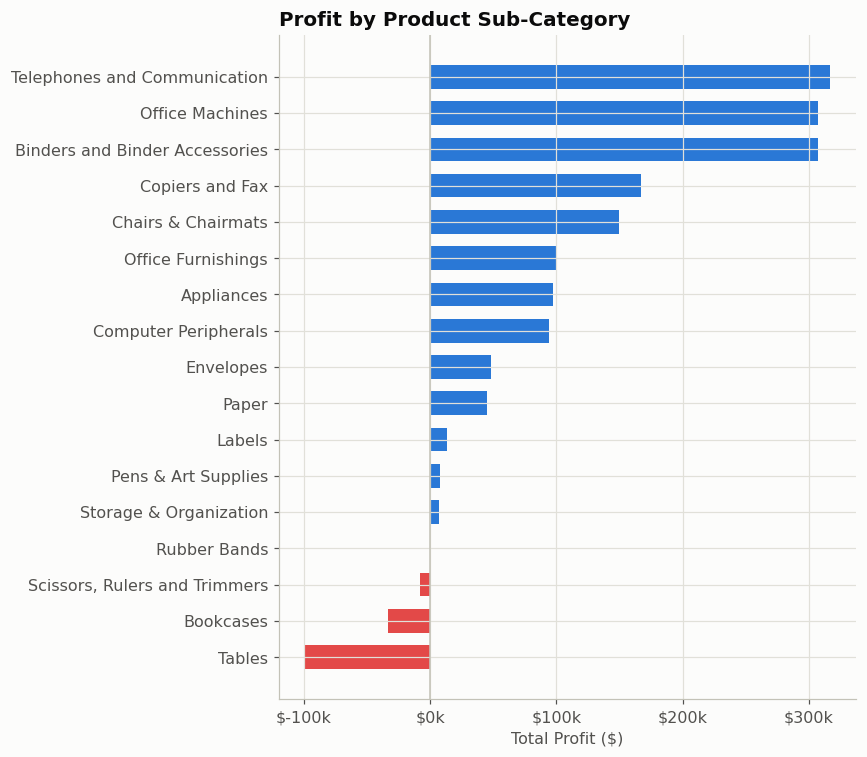

In [1]:
subcat = (df.groupby("Product Sub-Category")["Profit"]
            .sum().sort_values())

fig, ax = plt.subplots(figsize=(8, 7))
colors = [RED if v < 0 else BLUE for v in subcat.values]
ax.barh(subcat.index, subcat.values, color=colors, height=0.65)
ax.axvline(0, color="#c3c2b7", linewidth=1)
ax.set_title("Profit by Product Sub-Category", loc="left", fontsize=13, fontweight="bold")
ax.set_xlabel("Total Profit ($)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:,.0f}k"))
plt.tight_layout()
plt.show()

losers = subcat[subcat < 0]
print(f"{len(losers)} of {len(subcat)} sub-categories are net loss-making:")
print(losers.sort_values())


## 5. Does discounting help or hurt profit?

Conventional wisdom says discounts drive volume. Let's check whether they're eating profit.


Correlation between Discount and Profit: -0.04
discount_band
0%        248.9
1-10%     174.7
11-20%      4.9
21-30%   -249.4
Name: Profit, dtype: float64


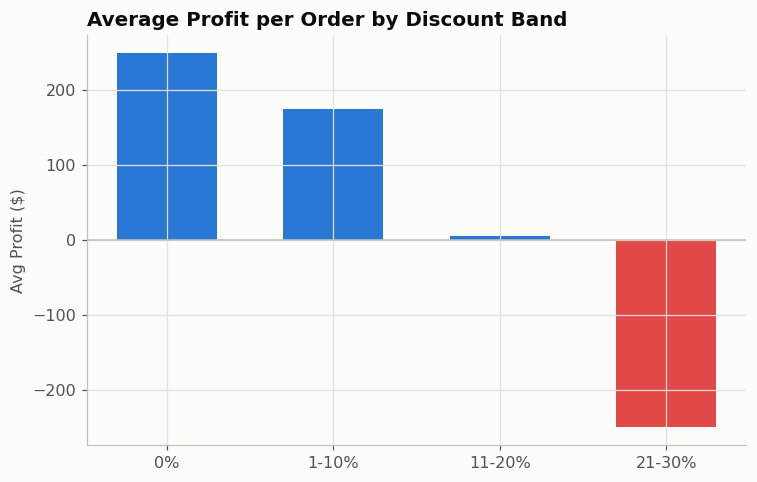

In [1]:
corr = df["Discount"].corr(df["Profit"])
print(f"Correlation between Discount and Profit: {corr:.2f}")

bins = [-0.01, 0, 0.1, 0.2, 0.3, 1.0]
labels = ["0%", "1-10%", "11-20%", "21-30%", "30%+"]
df["discount_band"] = pd.cut(df["Discount"], bins=bins, labels=labels)
band_profit = df.groupby("discount_band", observed=True)["Profit"].mean()

fig, ax = plt.subplots(figsize=(7, 4.5))
colors = [BLUE if v >= 0 else RED for v in band_profit.values]
ax.bar(band_profit.index.astype(str), band_profit.values, color=colors, width=0.6)
ax.axhline(0, color="#c3c2b7", linewidth=1)
ax.set_title("Average Profit per Order by Discount Band", loc="left", fontsize=13, fontweight="bold")
ax.set_ylabel("Avg Profit ($)")
plt.tight_layout()
plt.show()

print(band_profit.round(1))


## 6. Regional performance

                              Sales     Profit  Margin %
Region                                                  
West                   3.597549e+06  297008.61       8.3
Ontario                3.063212e+06  346868.54      11.3
Prarie                 2.837305e+06  321160.12      11.3
Atlantic               2.014248e+06  238960.66      11.9
Quebec                 1.510195e+06  140426.65       9.3
Yukon                  9.758674e+05   73849.21       7.6
Northwest Territories  8.008473e+05  100653.08      12.6
Nunavut                1.163765e+05    2841.11       2.4


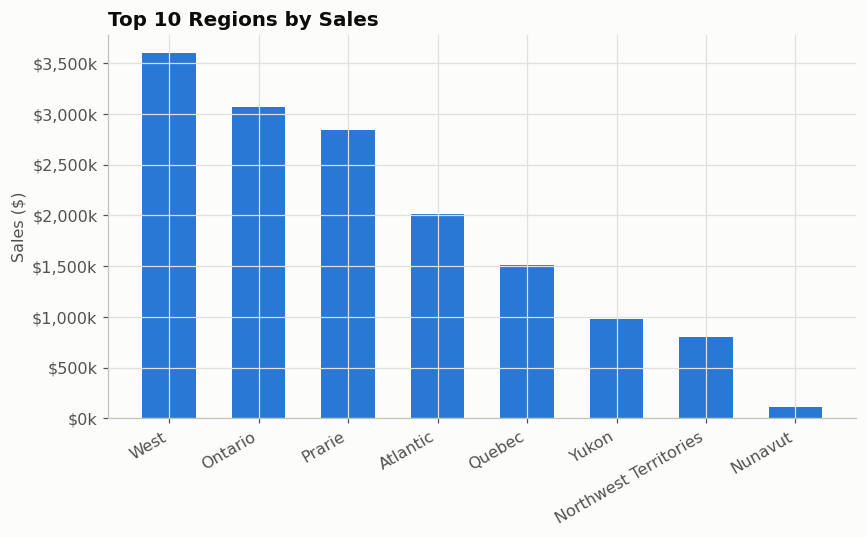

In [1]:
region = (df.groupby("Region")
            .agg(Sales=("Sales", "sum"), Profit=("Profit", "sum"))
            .sort_values("Sales", ascending=False)
            .head(10))
region["Margin %"] = (region["Profit"] / region["Sales"] * 100).round(1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(region.index, region["Sales"], color=BLUE, width=0.6, label="Sales")
ax.set_title("Top 10 Regions by Sales", loc="left", fontsize=13, fontweight="bold")
ax.set_ylabel("Sales ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:,.0f}k"))
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

print(region)


## 7. Sales trend over time

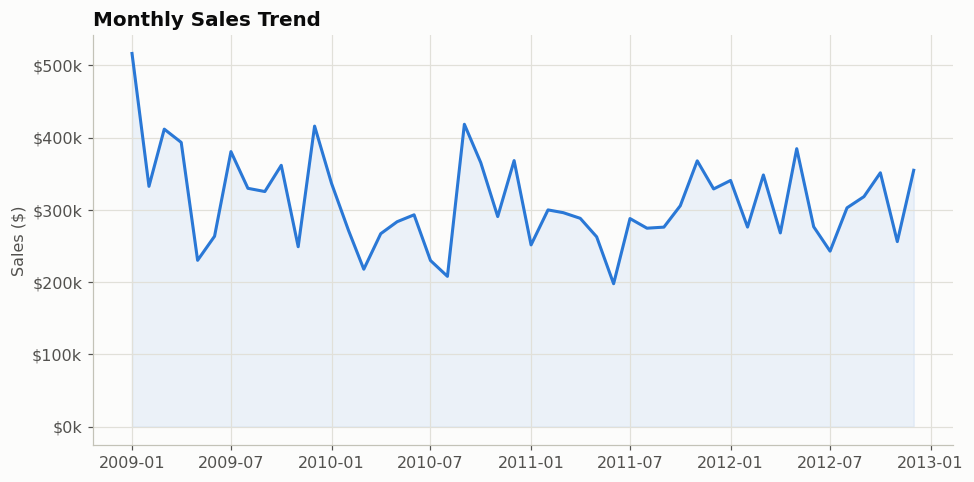

In [1]:
monthly = df.set_index("Order Date").resample("MS")["Sales"].sum()

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(monthly.index, monthly.values, color=BLUE, linewidth=2)
ax.fill_between(monthly.index, monthly.values, color=BLUE, alpha=0.08)
ax.set_title("Monthly Sales Trend", loc="left", fontsize=13, fontweight="bold")
ax.set_ylabel("Sales ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:,.0f}k"))
plt.tight_layout()
plt.show()


## 8. Customer segment value

                         Sales     Profit  Orders  Margin %  Profit per Order
Customer Segment                                                             
Corporate         5.498905e+06  599746.00    2002      10.9             300.0
Home Office       3.564764e+06  318354.03    1341       8.9             237.0
Small Business    2.788321e+06  315708.01    1077      11.3             293.0
Consumer          3.063611e+06  287959.94    1076       9.4             268.0


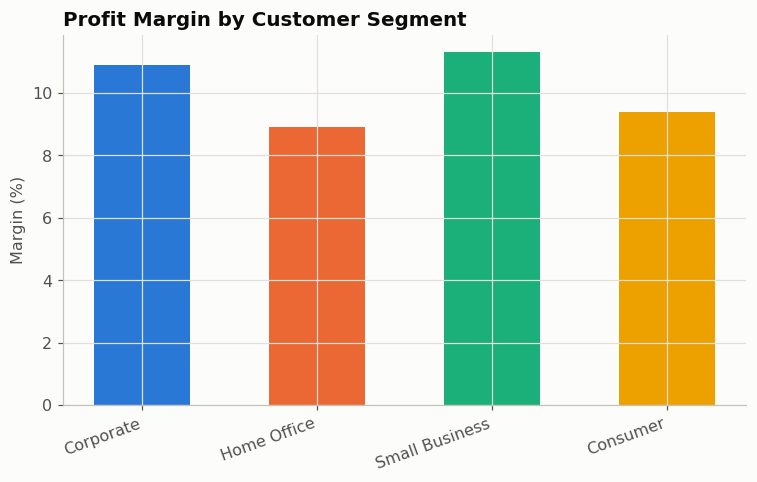

In [1]:
seg = (df.groupby("Customer Segment")
         .agg(Sales=("Sales", "sum"), Profit=("Profit", "sum"), Orders=("Order ID", "nunique"))
         .sort_values("Profit", ascending=False))
seg["Margin %"] = (seg["Profit"] / seg["Sales"] * 100).round(1)
seg["Profit per Order"] = (seg["Profit"] / seg["Orders"]).round(0)

fig, ax = plt.subplots(figsize=(7, 4.5))
colors = [BLUE, ORANGE, AQUA, "#eda100"][:len(seg)]
ax.bar(seg.index, seg["Margin %"], color=colors, width=0.55)
ax.set_title("Profit Margin by Customer Segment", loc="left", fontsize=13, fontweight="bold")
ax.set_ylabel("Margin (%)")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

print(seg)


## 9. Findings & recommendations

- **Several sub-categories are net loss-making** even though they generate real revenue — the business is subsidizing them through other categories. These are the first candidates for a pricing review or delisting.
- **Discounts above ~20% correlate with negative average profit per order.** The data doesn't support "discount harder to sell more" as a blanket strategy — discounting is only safe in the lower bands.
- **Sales are concentrated in a handful of regions**, which is a concentration risk worth flagging even though those regions look healthy today.
- **Customer segment margins vary meaningfully** — acquisition spend should be weighted toward the higher-margin segment rather than split evenly.

This mirrors how a first-week analyst task usually goes: start from KPIs, find where the profit is actually being made or lost (not just where the sales are), and end with 3-4 concrete, defensible recommendations rather than a wall of charts.
